# TactiFoot Vision: from dataset to tactical map

`tactifoot_vision` turns football broadcast video into tactical data: who is
where on the pitch, in which team, frame by frame. This notebook runs the
whole workflow once, one short step per stage. Each stage has its own
notebook with the details:

| stage | module | notebook |
|---|---|---|
| Data preparation | `tv.data` | [01_data](01_data.ipynb) |
| Data augmentation | `tv.augment` | [02_augmentation](02_augmentation.ipynb) |
| Training and evaluation | `tv.models`, `tv.evaluation` | [03_training_and_evaluation](03_training_and_evaluation.ipynb) |
| Inference | `tv.tracking`, `tv.pitch`, `tv.teams`, `tv.pipeline` | [04_inference](04_inference.ipynb) |
| Visualisation | `tv.viz` | [05_visualisation](05_visualisation.ipynb) |

Everything is plain Python: build the objects you want and call them. The
same steps exist as a command line (`tactifoot run`, `tactifoot train`), see
the README. Requirements and local data are listed in [README.md](README.md).

In [1]:
import os
from pathlib import Path

import tactifoot_vision as tv

# The repository root, found by walking up from the working directory and kept
# relative, so printed paths do not depend on where the repository lives.
_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file()
)
ROOT = Path(os.path.relpath(_root))
DATA, MODELS = ROOT / "data", ROOT / "models"
OUT = ROOT / "outputs" / "notebooks" / "00_overview"
VIDEO = DATA / "videos" / "broadcast_60s.mp4"

tv.setup_logging("WARNING")
# Most figures are video frames: JPEG keeps the saved notebook small.
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 85}}

## 1. Data

`tv.load_dataset` reads a YOLO or COCO dataset into a `Dataset`: images stay
on disk, labels in memory.

Dataset(name='football_yolo', task=detect, classes=['ball', 'goalkeeper', 'player', 'referee'], train=1259, valid=193)


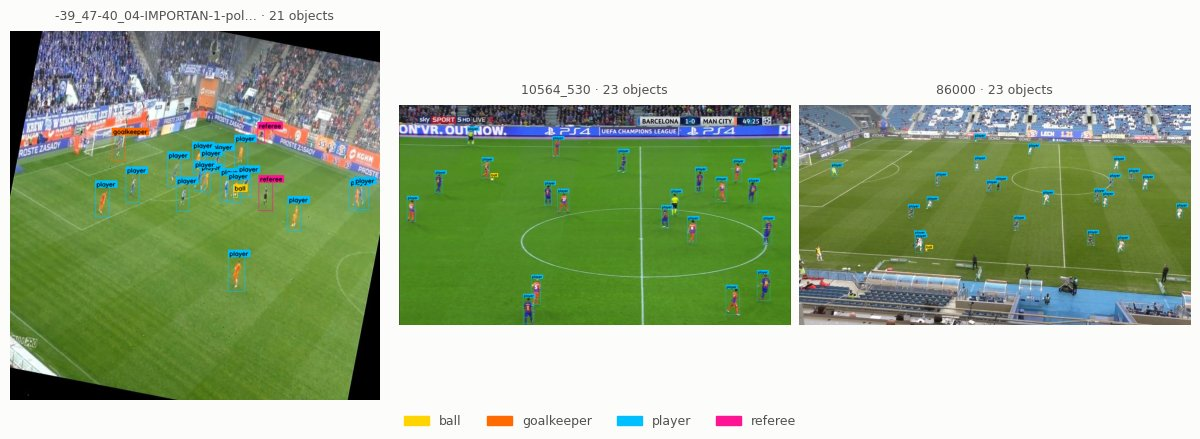

In [2]:
dataset = tv.load_dataset(DATA / "datasets" / "football_yolo")
print(dataset)
tv.viz.show_samples(dataset, "train", n=3)

## 2. Augmentation

Transforms move boxes and keypoints with the pixels. `augment_dataset` adds
augmented copies of the training images; validation images stay real. It
never overwrites earlier output, so a re-run starts from an empty folder.

In [3]:
import shutil

recipe = tv.augment.Compose(
    [
        tv.augment.HorizontalFlip(),
        tv.augment.RandomAffine(degrees=3, translate=0.05),
        tv.augment.ColorJitter(),
    ]
)
small = dataset.subset({"train": 100, "valid": 40}, seed=0)
shutil.rmtree(OUT / "augmented", ignore_errors=True)
augmented = tv.augment.augment_dataset(
    small, recipe, OUT / "augmented", copies=1, progress=False
)
augmented.summary()

,images,objects,ball,goalkeeper,player,referee
split,,,,,,
train,200,4225,198,110,3614,303
valid,40,822,42,15,722,43


## 3. Training and evaluation

`tv.train` works the same for every backend (`yolo`, `rfdetr`, `yolo_pose`).
This is a 15-epoch demo on 200 images; the checkpoints in `models/` were
trained the same way on the full datasets for far longer (200 epochs for the
YOLO models, about 30 for RF-DETR) and are used from here on. Both are scored
by the same evaluation code.

In [4]:
%%capture train_log
demo_run = tv.train(
    "yolo",
    augmented,
    weights="yolo11n.pt",
    epochs=15,
    batch_size=16,
    output_dir=OUT / "runs",
    name="yolo11n",
    exist_ok=True,
)

In [5]:
import pandas as pd

detector = tv.load_model("yolo", MODELS / "football_yolo11m.pt", conf=0.3)
scores = {
    "YOLO11n, 15-epoch demo": demo_run.load().evaluate(dataset),
    "YOLO11m, models/": detector.evaluate(dataset),
}
pd.DataFrame({name: m.as_dict() for name, m in scores.items()}).T.round(3)

,map50_95,map50,map75
"YOLO11n, 15-epoch demo",0.162,0.306,0.156
"YOLO11m, models/",0.452,0.782,0.465


## 4. Inference

The pipeline detects people and the ball, tracks them, maps them onto the
pitch through the pitch-landmark model, and splits players into teams by kit.

In [6]:
pipeline = tv.Pipeline(
    detector=detector,
    keypoint_model=tv.load_model("yolo_pose", MODELS / "pitch_yolov8n_pose.pt"),
    tracker="bytetrack",
    team_classifier=tv.teams.TeamClassifier(embedder="siglip"),
)
result = pipeline.run(VIDEO, end=250, progress=False)  # 10 seconds
print(len(result), "frames,", len(result.track_ids), "tracks")
result.to_dataframe().query("object == 'person'").head()

250 frames, 38 tracks


,frame,time,object,track_id,class_name,team_id,confidence,x1,y1,x2,y2,pitch_x,pitch_y
0,0,0.0,person,1,player,0,0.837460,1167.532104,262.105591,1181.763672,306.801544,65.860695,36.484665
1,0,0.0,person,2,player,0,0.820830,507.820129,362.145264,531.683899,411.203613,43.517876,41.029610
2,0,0.0,person,3,player,0,0.819493,356.377350,564.270386,381.926788,618.030518,40.897167,52.556580
3,0,0.0,person,4,player,1,0.816186,1327.150391,288.900574,1344.192505,333.207520,70.983147,39.493446
4,0,0.0,person,5,player,1,0.812782,1322.293579,519.817566,1347.726807,571.203003,67.074409,54.236786


`export` writes the run folder (`result.pkl`, `tracks.csv`, StatsBomb-style
`freeze_frames.csv`), the same files `tactifoot run` produces.

In [7]:
run_folder = result.export(OUT / "run")
sorted(p.name for p in run_folder.iterdir())

['freeze_frames.csv', 'result.pkl', 'tracks.csv']

## 5. Tactical map

One frame with tracks, teams and the projected pitch lines, plus the top-down
radar; then where each team spent the clip.

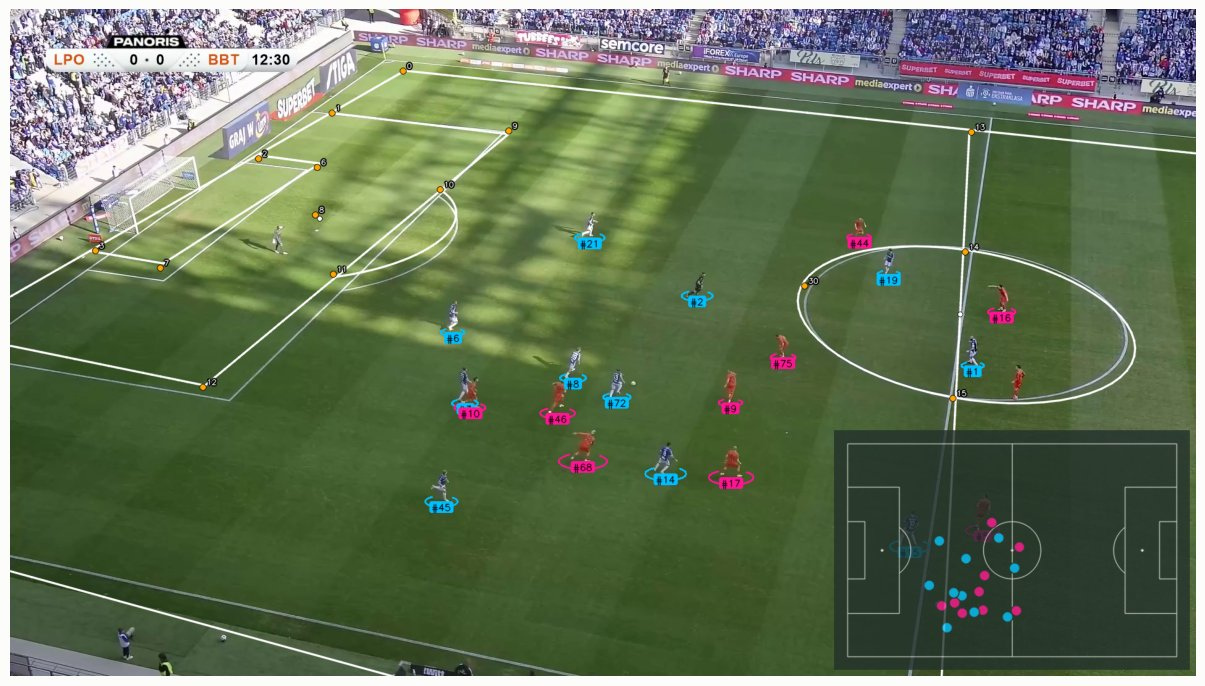

In [8]:
frame_result = result[200]
frame = tv.VideoReader(VIDEO).read(frame_result.index)
annotated = tv.viz.FrameAnnotator(style="video_game").annotate(frame, frame_result)
radar = tv.viz.PitchRadar().draw(frame_result)
tv.show(
    tv.viz.overlay(annotated, radar, position="bottom-right", width_fraction=0.3),
    width=12,
)

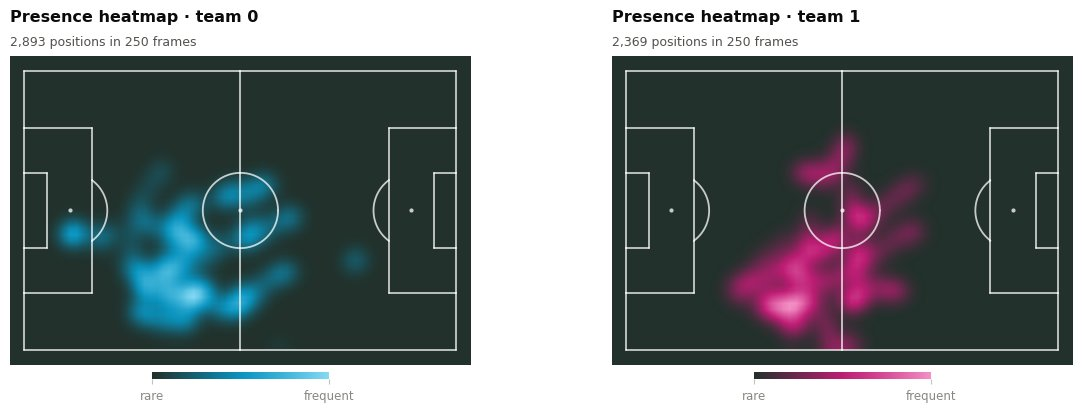

In [9]:
from matplotlib.figure import Figure

fig = Figure(figsize=(12, 4), layout="constrained")
for ax, team in zip(fig.subplots(1, 2), (0, 1), strict=True):
    tv.viz.plot_heatmap(result, team=team, ax=ax)
fig

## Next

* The module notebooks above go through every option.
* `tv.viz.render_video(result, VIDEO, "annotated.mp4")` writes the annotated
  clip ([05_visualisation](05_visualisation.ipynb)).
* The command line runs the same steps on whole matches:
  `tactifoot run configs/pipeline.yaml --video match.mp4 --output-dir outputs/match`,
  which is `tv.run_file.load("configs/pipeline.yaml").run("match.mp4", "outputs/match")`.